In [ ]:
# 1. Import libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
#extracting and loading dataset
import zipfile
zip_path = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
#printing contents of datasets
print(os.listdir("/content/dataset"))

['UTKFace', 'crop_part1', 'utkface_aligned_cropped']


In [ ]:
dataset_path = "/content/dataset/crop_part1"

In [ ]:
#extract age and create BMI
data = []

for file in os.listdir(dataset_path):
    try:
        age = int(file.split("_")[0])
        bmi = 18 + (age % 15)
        data.append([file, bmi])
    except:
        continue

df = pd.DataFrame(data, columns=["image", "bmi"])

In [ ]:
print(os.listdir(dataset_path)[:5])

['50_0_0_20170104184249918.jpg.chip.jpg', '3_0_0_20170110213730328.jpg.chip.jpg', '1_0_3_20161219230320824.jpg.chip.jpg', '43_0_0_20170105164829293.jpg.chip.jpg', '1_0_2_20161219203514252.jpg.chip.jpg']


In [ ]:
#load images
limit=1000
X = []
y = []

for index, row in df.iterrows():
    img_path = os.path.join(dataset_path, row["image"])

    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (96, 96))
        img = img / 255.0

        X.append(img)
        y.append(row["bmi"])
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Loaded images:", X.shape)


Loaded images: (9780, 96, 96, 3)


In [ ]:
df.to_csv("bmi_data.csv", index=False)

In [ ]:
df = pd.read_csv("bmi_data.csv")

In [ ]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#load mobilenet v2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(96,96,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freeze layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#custom layers
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
#compile
model.compile(
    optimizer=Adam(),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

In [ ]:
#train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
489/489 ━━━━━━━━━━━━━━━━━━━━ 77s 143ms/step - loss: 22.3502 - mean_absolute_error: 3.7601 - val_loss: 17.7917 - val_mean_absolute_error: 3.3974
Epoch 2/5
489/489 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - loss: 15.7872 - mean_absolute_error: 3.2235 - val_loss: 17.4104 - val_mean_absolute_error: 3.3518
Epoch 3/5
489/489 ━━━━━━━━━━━━━━━━━━━━ 95s 168ms/step - loss: 13.6502 - mean_absolute_error: 2.9794 - val_loss: 17.8900 - val_mean_absolute_error: 3.3769
Epoch 4/5
489/489 ━━━━━━━━━━━━━━━━━━━━ 77s 158ms/step - loss: 12.3805 - mean_absolute_error: 2.8340 - val_loss: 18.8480 - val_mean_absolute_error: 3.5370
Epoch 5/5
489/489 ━━━━━━━━━━━━━━━━━━━━ 71s 145ms/step - loss: 11.6598 - mean_absolute_error: 2.7517 - val_loss: 21.5218 - val_mean_absolute_error: 3.7286


In [ ]:
#evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test MAE:", mae)


62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - loss: 21.5218 - mean_absolute_error: 3.7286
Test Loss: 21.521785736083984
Test MAE: 3.7285969257354736


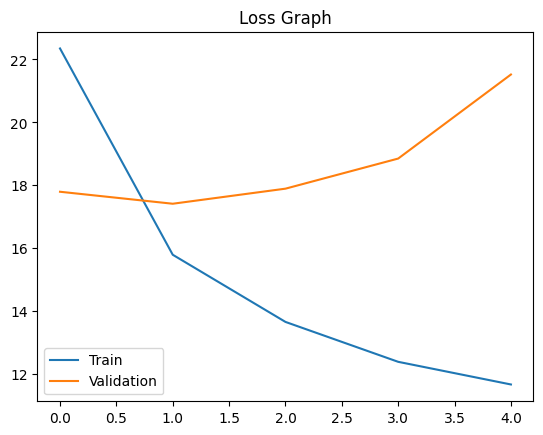

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Graph")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
#BMI categorising
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    else:
        return "Overweight"

In [ ]:
#prediction
def predict_bmi(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (96, 96))
    img = img / 255.0
    img = np.reshape(img, (1, 96, 96, 3))

    pred = model.predict(img)
    bmi_value = pred[0][0]

    category = categorize_bmi(bmi_value)

    print("Predicted BMI:", bmi_value)
    print("Category:", category)

In [ ]:
predict_bmi("/content/dataset/crop_part1/100_1_0_20170110183726390.jpg.chip.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted BMI: 23.26307
Category: Normal


In [ ]:
import matplotlib.pyplot as plt

def show_prediction(image_path):
    img = cv2.imread("/content/dataset/crop_part1/10_0_0_20170104013211746.jpg.chip.jpg")
    img_resized = cv2.resize(img, (96,96)) / 255.0
    img_input = np.reshape(img_resized, (1,96,96,3))

    pred = model.predict(img_input)[0][0]
    category = categorize_bmi(pred)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"BMI: {pred:.2f} ({category})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


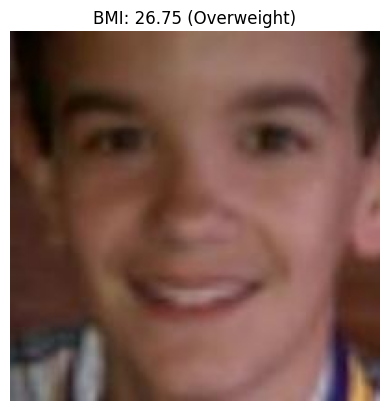

In [ ]:
show_prediction("/content/dataset/crop_part1/10_0_0_20170104013211746.jpg.chip.jpg")